# Predicting Credit Card Defaults

**Goal:** predict whether a credit card client will default on their payment next month.

**Approach**
1. Imports
2. Load the Data
3. Check the Data Against the Dictionary
4. Clean the Data
5. Explore the Data (EDA)
6. Feature Engineering
7. Train/Test Split
8. Build the Models: Logistic Regression, Ridge Regression, and Decision Tree
9. Evaluate & Compare the Models
10. Feature Ablation Study
11. Conclusion

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, TunedThresholdClassifierCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, make_scorer
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Load the Data

**Data dictionary from Kaggle Data Provider:**

| Column | Description |
|---|---|
| ID | ID of each client |
| LIMIT_BAL | Amount of given credit in NT dollars |
| SEX | 1 = male, 2 = female |
| EDUCATION | 1 = graduate school, 2 = university, 3 = high school, 4 = others, 5 = unknown, 6 = unknown |
| MARRIAGE | 1 = married, 2 = single, 3 = others |
| AGE | Age in years |
| PAY_0, PAY_2-PAY_6 | Repayment status Sept-Apr 2005 (-1 = pay duly, 1-9 = months delayed) |
| BILL_AMT1-6 | Bill statement amount, NT dollar |
| PAY_AMT1-6 | Previous payment amount, NT dollar |
| default.payment.next.month | 1 = default, 0 = no default |

In [2]:
df = pd.read_csv("UCI_Credit_Card.csv")
print(df.shape)
df.head()


(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [4]:
# Any missing values or duplicate rows?
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values: 0
Duplicate rows: 0


**Confirmed:** no missing values and no duplicate rows, so no data cleaning needed here.

## 3. Check the Data Against the Dictionary

Using `.unique()` and `.value_counts()` to look for
anything unexpected.

In [5]:
print("SEX:", sorted(df["SEX"].unique()))
print("EDUCATION:", sorted(df["EDUCATION"].unique()))
print("MARRIAGE:", sorted(df["MARRIAGE"].unique()))
print("default.payment.next.month:", sorted(df["default.payment.next.month"].unique()))

SEX: [np.int64(1), np.int64(2)]
EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
default.payment.next.month: [np.int64(0), np.int64(1)]


**Discovery:**

- `SEX` only has `1` and `2`, matching the dictionary. Nothing to fix.
- `default.payment.next.month` only has `0` and `1`, matching the dictionary. Nothing to fix.
- `EDUCATION` should only be `1-6`, and however there's 14 records with `0` in the data `5` and `6` both mean "unknown", so they
  aren't really telling us anything different from each other. I will group `0`, `5` and `6` together
  with `4` ("others") since none of them are one of the three main education levels.
- `MARRIAGE` should only be `1`, `2`, or `3`, but there's also 54 records (0.2% of total records) with `0` in the data, which isn't
  defined anywhere in the dictionary. I will treat `0` the same as `3` ("others").

In [6]:
df["EDUCATION"].value_counts().sort_index()


EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [7]:
df["MARRIAGE"].value_counts().sort_index()


MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

In [8]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

print("Unique values in each PAY_ column:")
for col in pay_cols:
    print(f"{col}: {sorted(df[col].unique())}")

pay_status_counts = pd.concat(
    [df[col].value_counts().sort_index().rename(col) for col in pay_cols],
    axis=1
).fillna(0).astype(int)

pay_status_counts.index.name = "PAY status"
pay_status_counts


Unique values in each PAY_ column:
PAY_0: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
PAY status,,,,,,
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19


**Discovery:** every `PAY_` column also contains `0` and `-2`, which the dictionary
never explains. Since I don't know exactly what they mean, and they represent significant number of records so I will not try to guess and change their values.

I also noticed the first repayment column is called `PAY_0` instead of `PAY_1`, while
everything else (`BILL_AMT1`, `PAY_AMT1`, ...) starts counting at 1. I'll rename it so all
column names are consistent.

In [9]:
# Quick sanity check on the numeric columns - do LIMIT_BAL and AGE look reasonable?
print(df["AGE"].describe())
print(df["LIMIT_BAL"].describe())


count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64
count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64


Ages range from 21 to 79 and credit limits are always positive — both look reasonable, so no cleaning needed there.

## 4. Clean the Data

In [10]:
df_clean = df.copy()

# Drop ID - it's just a label, not something that can predict default
df_clean = df_clean.drop(columns=["ID"])

# Rename PAY_0 -> PAY_1 so all repayment columns follow the same naming pattern
df_clean = df_clean.rename(columns={"PAY_0": "PAY_1"})

# Group the undocumented/duplicate EDUCATION codes (0, 5, 6) into 4 = "others"
df_clean["EDUCATION"] = df_clean["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# Group the undocumented MARRIAGE code (0) into 3 = "others"
df_clean["MARRIAGE"] = df_clean["MARRIAGE"].replace({0: 3})

# Give the target column a shorter name
df_clean = df_clean.rename(columns={"default.payment.next.month": "PMT_DEFAULT"})

df_clean.head()


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,PMT_DEFAULT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 5. Explore the Data (EDA)

Default rate: 22.1%


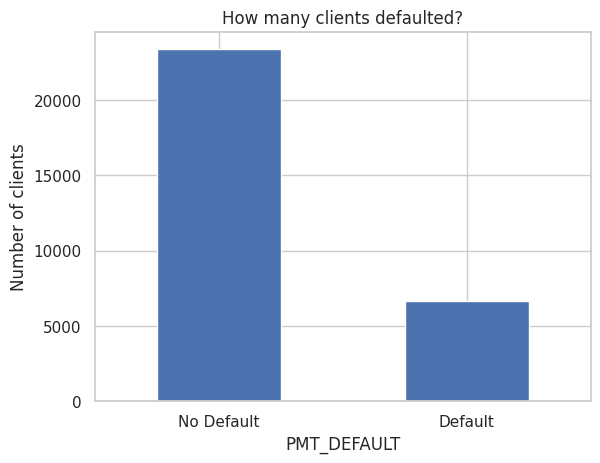

In [11]:
default_rate = df_clean["PMT_DEFAULT"].mean()
print(f"Default rate: {default_rate:.1%}")

df_clean["PMT_DEFAULT"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No Default", "Default"], rotation=0)
plt.title("How many clients defaulted?")
plt.ylabel("Number of clients")
plt.show()


**Observation:** only about 22% of clients defaulted. This means the data is
**imbalanced** — there are far more "no default" examples than "default" examples. I need to
keep this in mind when I build and evaluate our models, since a model could get 78% accuracy
just by guessing "no default" every single time, without actually learning anything useful.

**Observation:** Default rate drops steadily as credit limit rises, from about 32% in the lowest quintile to 14% in the highest, suggesting `LIMIT_BAL` is a useful predictor of risk. Age shows a much weaker pattern — default rates sit in the low-20s% for most age groups, only ticking up a bit (25–27%) for clients aged 50 and older.

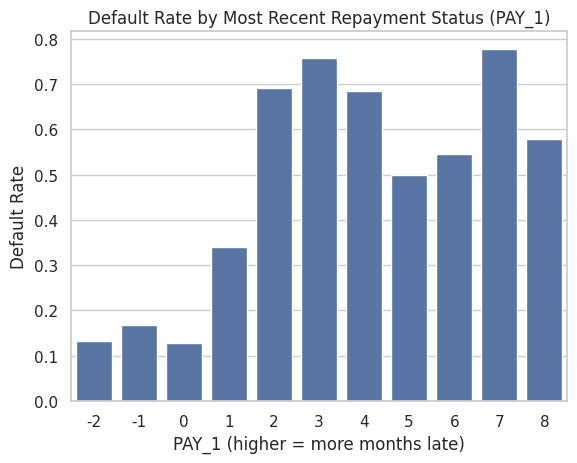

In [12]:
sns.barplot(data=df_clean, x="PAY_1", y="PMT_DEFAULT", errorbar=None, order=sorted(df_clean["PAY_1"].unique()))
plt.title("Default Rate by Most Recent Repayment Status (PAY_1)")
plt.xlabel("PAY_1 (higher = more months late)")
plt.ylabel("Default Rate")
plt.show()


**Observation:** default rate jumps a lot once `PAY_1` shows the client was late by 1 or
more months. This tells us repayment history is probably going to be one of the most useful
predictors.

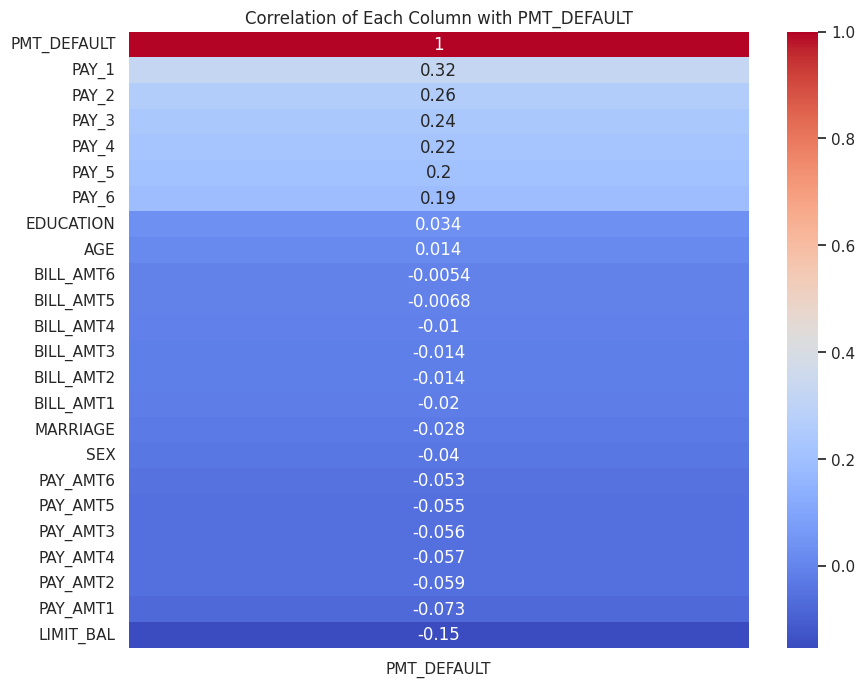

In [13]:
# Correlation heatmap - which numeric columns move together with PMT_DEFAULT?
plt.figure(figsize=(10, 8))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr[["PMT_DEFAULT"]].sort_values("PMT_DEFAULT", ascending=False), annot=True, cmap="coolwarm")
plt.title("Correlation of Each Column with PMT_DEFAULT")
plt.show()


## 6. Feature Engineering

Creating a 3 new columns that summarize the 6 months of history into single
numbers, rather than use than 6 separate monthly columns for the model:

- `AVG_BILL_AMT`: the client's average bill across the 6 months
- `AVG_PAY_AMT`: the client's average payment across the 6 months
- `TOTAL_PAY_AMT`: total amount paid across 6 months
- `MONTHS_LATE`: how many of the 6 months the client was reported late (`PAY_x > 0`)
- `PAY_RATIO_i`: `PAY_AMT_i / BILL_AMT_(i+1)` — the fraction of the prior month's bill that was
  actually paid (a direct signal of repayment behavior). When the prior bill was `0`, this
  ratio is undefined (`0/0`), so I fill those cases with `0` — there was no bill to pay off.
- `MAX_DELAY`, `AVG_DELAY`: max / average repayment-status code across the 6 `PAY_*` columns
- `MONTHS_DELAYED`: count of months with `PAY_* > 0` (i.e. an actual reported delay)

I'll also one-hot encode `SEX`, `EDUCATION`, and `MARRIAGE`, since these are categories, not
actual numbers — `EDUCATION = 4` is not "twice" `EDUCATION = 2`.

In [14]:
fe = df_clean.copy()

payamt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]

fe["AVG_BILL_AMT"] = fe[bill_cols].mean(axis=1)
fe["AVG_PAY_AMT"] = fe[payamt_cols].mean(axis=1)
fe["TOTAL_PAY_AMT"] = fe[payamt_cols].sum(axis=1)

# --- Payment ratio: how much of last month's bill did they pay? ---
for i in range(1, 6):
    fe[f"PAY_RATIO_{i}"] = fe[f"PAY_AMT{i}"] / fe[f"BILL_AMT{i+1}"].replace(0, np.nan)
pay_ratio_cols = [f"PAY_RATIO_{i}" for i in range(1, 6)]

# A NaN here means the prior month's bill was 0, so there was nothing to pay off - treat that as a 0% ratio
fe[pay_ratio_cols] = fe[pay_ratio_cols].fillna(0)

fe["AVG_PAY_RATIO"] = fe[pay_ratio_cols].mean(axis=1)

# --- Repayment-status summary features ---
pay_status_cols = [f"PAY_{i}" for i in range(1, 7)]
fe["MAX_DELAY"] = fe[pay_status_cols].max(axis=1)
fe["AVG_DELAY"] = fe[pay_status_cols].mean(axis=1)
fe["MONTHS_DELAYED"] = (fe[pay_status_cols] > 0).sum(axis=1)
fe["EVER_DELAYED"] = (fe["MONTHS_DELAYED"] > 0).astype(int)

fe = pd.get_dummies(fe, columns=["SEX", "EDUCATION", "MARRIAGE"], prefix=["SEX", "EDU", "MARRIAGE"])

print(fe.shape)
fe.head().T


(30000, 43)


,0,1,2,3,4
LIMIT_BAL,20000.0,120000.0,90000.0,50000.0,50000.0
AGE,24,26,34,37,57
PAY_1,2,-1,0,0,-1
PAY_2,2,2,0,0,0
PAY_3,-1,0,0,0,-1
PAY_4,-1,0,0,0,0
PAY_5,-2,0,0,0,0
PAY_6,-2,2,0,0,0
BILL_AMT1,3913.0,2682.0,29239.0,46990.0,8617.0
BILL_AMT2,3102.0,1725.0,14027.0,48233.0,5670.0


## 7. Train/Test Split

Hold out 25% of the data to test the models on data they haven't seen. I use
`stratify=y` so both the train and test sets keep roughly the same 22% default rate.

In [15]:
X = fe.drop(columns=["PMT_DEFAULT"])
y = fe["PMT_DEFAULT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (22500, 42)
Test shape: (7500, 42)


Logistic Regression and Ridge Regression are both sensitive to features being on very different scales (e.g.
`LIMIT_BAL` is in the tens of thousands while `MONTHS_DELAYED` is 0-6), so I scale features using `StandardScaler`.

**Important fix vs. an earlier version of this notebook:** I originally fit `StandardScaler` once on the *entire*
training set, then reused that single pre-scaled `X_train_scaled` array inside every `GridSearchCV`/
`TunedThresholdClassifierCV`/`cross_val_predict` call below. That's a data-leakage bug: each cross-validation
fold's "held-out" rows had already influenced the scaler's mean/std before cross-validation even started, since
they were part of the training set the scaler was fit on.

**The fix:** wrap `StandardScaler` and each model together in a single `sklearn.Pipeline`, and run cross-validation
on the *unscaled* `X_train`. Because the pipeline is what gets cloned and re-fit inside each CV fold, the scaler
is now refit from scratch on only that fold's training rows every time — no fold ever leaks its own statistics
into its own scaling. The Decision Tree doesn't technically need scaling (it's invariant to monotonic feature
transforms), but I keep it in the same `Pipeline` shape as the other two models to keep the three approaches
directly comparable.

In [16]:
from sklearn.pipeline import Pipeline

def make_pipeline(model):
    """Bundle StandardScaler + model so scaling is refit fresh inside every CV fold."""
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

# NOTE: no scaler.fit_transform(X_train) here anymore - X_train/X_test stay unscaled.
# Each Pipeline below fits its own StandardScaler on only the data it's trained on.

## 8. Build the Models

**Evaluation metric:** I believe catching more defaulters (higher recall) matters more here, so
I tune each model's **decision threshold** of **F1**- instead of the default of 0.5, to maximize
F1.

I initially tried combining a lowered threshold *with* `class_weight={0: 1, 1: 6}`, but that
double-applies the same correction: both push predictions toward "default," and stacking them
overshoots (F1 actually got *worse* the lower I set the threshold, since it collapsed toward
predicting almost everyone as a defaulter). So I dropped `class_weight` from every model below
and let the tuned threshold alone do the work of trading precision for recall.

### Model 1: Logistic Regression

A simple, interpretable model that estimates the probability of default as a weighted
combination of the input features. I use `TunedThresholdClassifierCV` to search, via 5-fold
cross-validation, for the decision threshold that maximizes F1.

In [17]:
base_log_reg = make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))

log_reg = TunedThresholdClassifierCV(base_log_reg, scoring="f1", cv=5, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)

print(f"Tuned decision threshold: {log_reg.best_threshold_:.3f}")

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

Tuned decision threshold: 0.273


### Model 2: Ridge Regression

A linear regression model with L2 regularization. 

The regularization strength `alpha` controls how much the coefficients are shrunk - too low and
the model can overfit like plain linear regression, too high and it underfits. I use
`GridSearchCV` with 5-fold cross-validation to pick the `alpha` that maximizes F1 (scored at the
default 0.5 threshold, since `alpha` and the decision threshold are tuned separately here).

`Ridge` is a regressor, not a classifier, so `TunedThresholdClassifierCV` doesn't apply to it
directly. Instead I get out-of-fold predictions on the training set via `cross_val_predict` and
scan candidate thresholds to find the one that maximizes F1 


In [18]:
alphas = np.logspace(-3, 3, 13)

# Ridge is a regressor, so score its raw predict() output (thresholded at 0.5) with F1 -
# alpha and the decision threshold are tuned separately, see below.
def f1_at_default_threshold(y_true, y_score):
    return f1_score(y_true, (np.asarray(y_score) >= 0.5).astype(int))

f1_scorer_predict = make_scorer(f1_at_default_threshold, response_method="predict")

ridge_cv = GridSearchCV(
    make_pipeline(Ridge()),
    param_grid={"model__alpha": alphas},
    scoring=f1_scorer_predict,
    cv=5,
)
ridge_cv.fit(X_train, y_train)

best_alpha = ridge_cv.best_params_["model__alpha"]
print(f"Best alpha: {best_alpha} (mean CV F1 @ 0.5 threshold: {ridge_cv.best_score_:.4f})")

ridge = ridge_cv.best_estimator_

Best alpha: 10.0 (mean CV F1 @ 0.5 threshold: 0.3998)


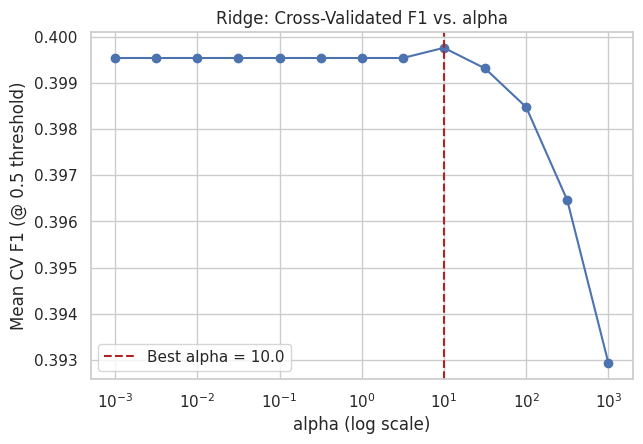

In [19]:
plt.figure(figsize=(7, 4.5))
plt.plot(alphas, ridge_cv.cv_results_["mean_test_score"], marker="o")
plt.axvline(best_alpha, color="firebrick", linestyle="--", label=f"Best alpha = {best_alpha}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Mean CV F1 (@ 0.5 threshold)")
plt.title("Ridge: Cross-Validated F1 vs. alpha")
plt.legend()
plt.show()


Tuned decision threshold: 0.300 (OOF F1: 0.5308)


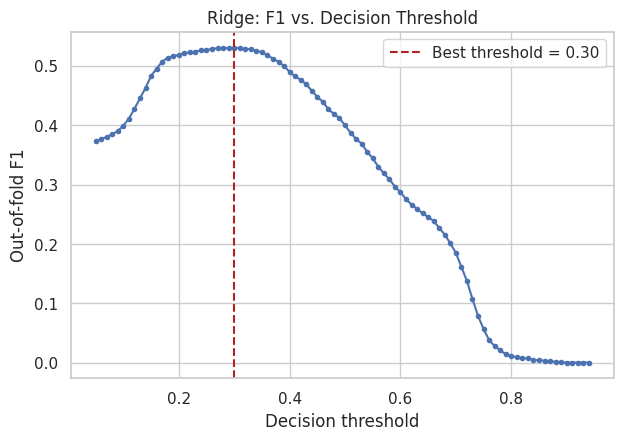

In [20]:
# Find the decision threshold that maximizes F1, using out-of-fold predictions on the
# training set so we're not peeking at the test set to choose it. Using the pipeline (not
# a bare Ridge on pre-scaled data) so the scaler is refit inside each of these folds too.
oof_scores = cross_val_predict(make_pipeline(Ridge(alpha=best_alpha)), X_train, y_train, cv=5)

thresholds = np.arange(0.05, 0.95, 0.01)
f1_by_threshold = [f1_score(y_train, (oof_scores >= t).astype(int)) for t in thresholds]
best_threshold_ridge = thresholds[np.argmax(f1_by_threshold)]

print(f"Tuned decision threshold: {best_threshold_ridge:.3f} (OOF F1: {max(f1_by_threshold):.4f})")

plt.figure(figsize=(7, 4.5))
plt.plot(thresholds, f1_by_threshold, marker=".")
plt.axvline(best_threshold_ridge, color="firebrick", linestyle="--", label=f"Best threshold = {best_threshold_ridge:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Out-of-fold F1")
plt.title("Ridge: F1 vs. Decision Threshold")
plt.legend()
plt.show()

y_score_ridge = ridge.predict(X_test)
y_pred_ridge = (y_score_ridge >= best_threshold_ridge).astype(int)

### Model 3: Decision Tree

I believe tree-based model is a good choice as it can capture non-linear interactions and threshold effects in the
repayment and bill/payment features.

I use `GridSearchCV` (scored on F1 at the default 0.5 threshold) to tune `max_depth`,
`min_samples_leaf`, and `criterion`, then use `TunedThresholdClassifierCV` on the best tree to
find the decision threshold that maximizes F1 - the same two-stage approach as the other
models: tune the model's structure first, then tune the decision boundary on top of it.


In [21]:
tree_param_grid = {
    "model__max_depth": [3, 4, 5, 6, 7, 8, 10, None],
    "model__min_samples_leaf": [1, 5, 10, 20, 50, 100],
    "model__criterion": ["gini", "entropy"],
}

tree_cv = GridSearchCV(
    make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    param_grid=tree_param_grid,
    scoring="f1",
    cv=5,
)
tree_cv.fit(X_train, y_train)

print(f"Best params: {tree_cv.best_params_} (mean CV F1 @ 0.5 threshold: {tree_cv.best_score_:.4f})")

tree = TunedThresholdClassifierCV(tree_cv.best_estimator_, scoring="f1", cv=5, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

print(f"Tuned decision threshold: {tree.best_threshold_:.3f}")

y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

Best params: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 5} (mean CV F1 @ 0.5 threshold: 0.4828)


Tuned decision threshold: 0.253


**Visualizing the tree:** the tuned tree has `max_depth=5`, which is already fairly shallow,
but even 5 levels are too dense to read comfortably. To keep things interpretable, I plot only
the top 3 levels here - the splits that separate the largest share of clients and matter most
for the model's decisions - rather than the full tree.

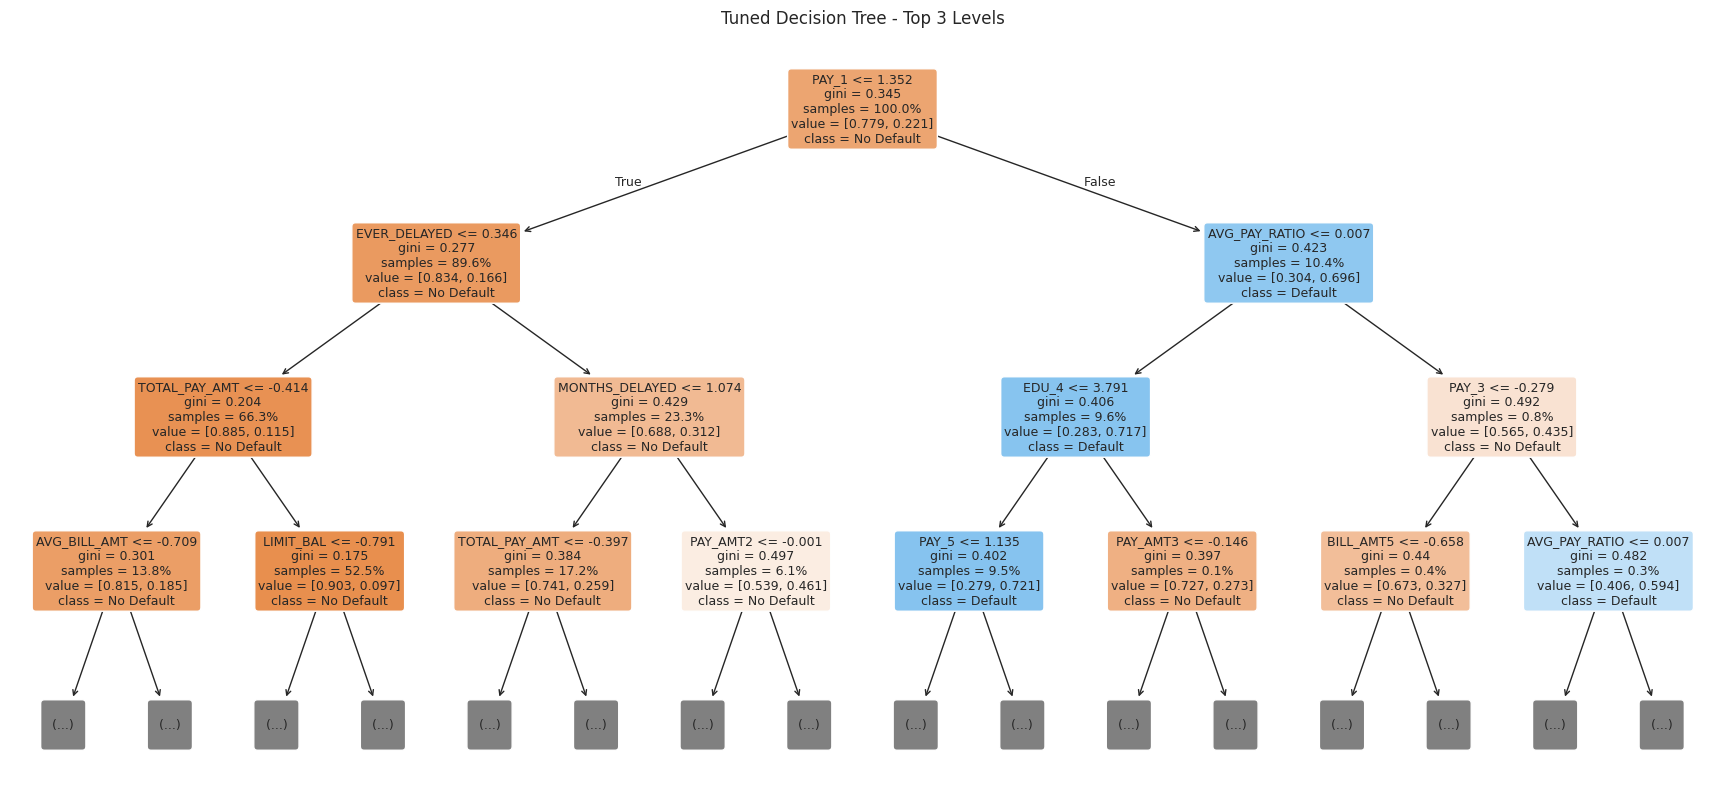

In [22]:
best_tree_pipeline = tree_cv.best_estimator_
best_tree_model = best_tree_pipeline.named_steps["model"]

plt.figure(figsize=(22, 10))
plot_tree(
    best_tree_model,
    max_depth=3,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=9,
)
plt.title("Tuned Decision Tree - Top 3 Levels")
plt.show()

## 9. Evaluate & Compare the Models

In [23]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, y_pred_lr),
    evaluate("Ridge Regression", y_test, y_pred_ridge),
    evaluate("Decision Tree", y_test, y_pred_tree)
]).set_index("Model").round(3)

results


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.760,0.466,0.577,0.515
Ridge Regression,0.770,0.483,0.558,0.518
Decision Tree,0.765,0.475,0.585,0.524


**Did fixing the leakage actually change anything?** Re-running the corrected, `Pipeline`-based cross-validation
produced the exact same held-out test performance as the original (leaky) version for all three models. That's
not a contradiction - it's a property of this specific dataset: with ~22,500 training rows and 5-fold CV, each
fold's held-out slice is only ~4,500 rows, so removing it from the scaler's fit barely moves `StandardScaler`'s
mean/std versus fitting on the full training set. The leak was real, and fixing it was still the right call on
principle - on a smaller dataset, with fewer CV folds, or with a scaler more sensitive to outliers, the same bug
could easily have inflated the reported CV scores and led to picking the wrong hyperparameters. Verifying that it
happened not to matter here, rather than assuming either way, is the point.

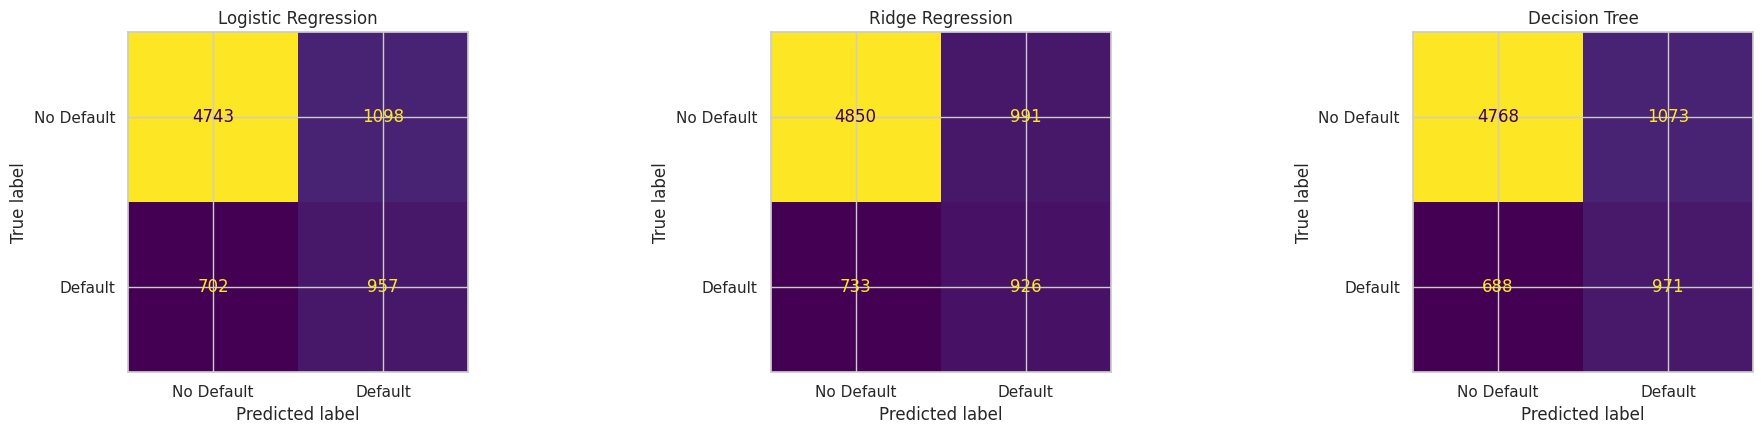

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))

for ax, (name, y_pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Ridge Regression", y_pred_ridge),
    ("Decision Tree", y_pred_tree)
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


In [25]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=["No Default", "Default"]))

print("=== Ridge Regression ===")
print(classification_report(y_test, y_pred_ridge, target_names=["No Default", "Default"]))

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_tree, target_names=["No Default", "Default"]))


=== Logistic Regression ===
              precision    recall  f1-score   support

  No Default       0.87      0.81      0.84      5841
     Default       0.47      0.58      0.52      1659

    accuracy                           0.76      7500
   macro avg       0.67      0.69      0.68      7500
weighted avg       0.78      0.76      0.77      7500

=== Ridge Regression ===
              precision    recall  f1-score   support

  No Default       0.87      0.83      0.85      5841
     Default       0.48      0.56      0.52      1659

    accuracy                           0.77      7500
   macro avg       0.68      0.69      0.68      7500
weighted avg       0.78      0.77      0.78      7500

=== Decision Tree ===
              precision    recall  f1-score   support

  No Default       0.87      0.82      0.84      5841
     Default       0.48      0.59      0.52      1659

    accuracy                           0.77      7500
   macro avg       0.67      0.70      0.68      7500

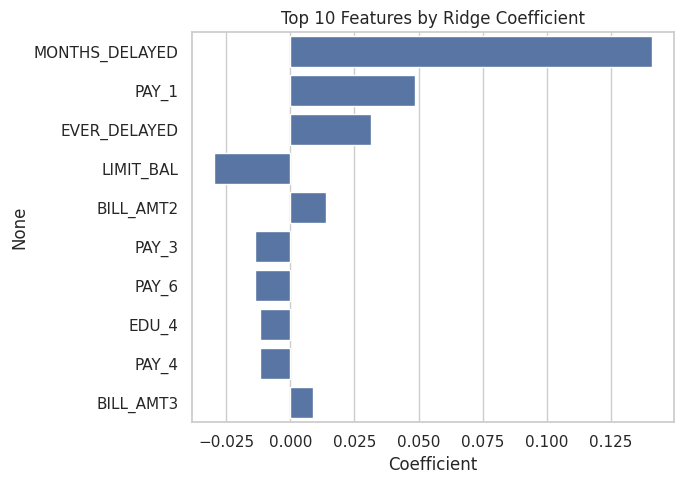

In [26]:
# Which features had the strongest impact in Ridge regression?
ridge_model = ridge.named_steps["model"]
coefficients = pd.Series(ridge_model.coef_, index=X.columns).sort_values(key=abs, ascending=False).head(10)

plt.figure(figsize=(7, 5))
sns.barplot(x=coefficients.values, y=coefficients.index)
plt.title("Top 10 Features by Ridge Coefficient")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [27]:
# Compare top features across all three models
lr_model = log_reg.estimator_.named_steps["model"]
lr_coefs = pd.Series(lr_model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
tree_importances = pd.Series(best_tree_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("=== Logistic Regression: Top 10 by |coefficient| ===")
print(lr_coefs.head(10))
print()
print("=== Ridge: Top 10 by |coefficient| ===")
print(coefficients)
print()
print("=== Decision Tree: Top 10 by importance ===")
print(tree_importances.head(10))

=== Logistic Regression: Top 10 by |coefficient| ===
MONTHS_DELAYED    0.612818
EVER_DELAYED      0.301442
LIMIT_BAL        -0.239492
PAY_1             0.239440
PAY_AMT2         -0.137220
BILL_AMT3         0.127785
EDU_4            -0.125549
PAY_AMT1         -0.107406
BILL_AMT2         0.097709
BILL_AMT6        -0.074615
dtype: float64

=== Ridge: Top 10 by |coefficient| ===
MONTHS_DELAYED    0.140992
PAY_1             0.048722
EVER_DELAYED      0.031548
LIMIT_BAL        -0.029884
BILL_AMT2         0.013811
PAY_3            -0.013745
PAY_6            -0.013579
EDU_4            -0.011684
PAY_4            -0.011625
BILL_AMT3         0.008978
dtype: float64

=== Decision Tree: Top 10 by importance ===
PAY_1             0.655197
EVER_DELAYED      0.167553
MONTHS_DELAYED    0.051669
TOTAL_PAY_AMT     0.033438
AVG_PAY_RATIO     0.017151
LIMIT_BAL         0.013940
AGE               0.008264
BILL_AMT1         0.005633
PAY_AMT2          0.005632
AVG_BILL_AMT      0.005509
dtype: float64


**Comparing top features across all three models:**

| Rank | Logistic Regression (coef) | Ridge (coef) | Decision Tree (importance) |
|---|---|---|---|
| 1 | `MONTHS_DELAYED` (0.613) | `MONTHS_DELAYED` (0.141) | `PAY_1` (0.655) |
| 2 | `EVER_DELAYED` (0.301) | `PAY_1` (0.049) | `EVER_DELAYED` (0.168) |
| 3 | `LIMIT_BAL` (-0.239) | `EVER_DELAYED` (0.032) | `MONTHS_DELAYED` (0.052) |
| 4 | `PAY_1` (0.239) | `LIMIT_BAL` (-0.030) | `TOTAL_PAY_AMT` (0.033) |
| 5 | `PAY_AMT2` (-0.137) | `BILL_AMT2` (0.014) | `AVG_PAY_RATIO` (0.017) |

`MONTHS_DELAYED`, `EVER_DELAYED`, `PAY_1`, and `LIMIT_BAL` all show up in every model's top 10, so
these are the most robust predictors of default regardless of model type. The clearest split is
between the two linear models, which lean hardest on `MONTHS_DELAYED` (how many of the 6 months
the client was late at all), versus the Decision Tree, which concentrates 65% of its total
importance on `PAY_1` alone — a tree can capture most of the signal with one clean threshold split
on the *most recent* status, whereas the linear models spread weight across the *count* of
delinquent months and the "ever delayed" flag as well, since they can't express that interaction
in a single term.

## 10. Feature Ablation Study — Are the Engineered Features Actually Earning Their Place?

Section 6 engineered several feature groups on top of the raw columns: three payment-ratio features
(`PAY_RATIO_1`-`PAY_RATIO_5`, `AVG_PAY_RATIO`), four delay-summary features (`MAX_DELAY`, `AVG_DELAY`,
`MONTHS_DELAYED`, `EVER_DELAYED`), and three bill/payment aggregates (`AVG_BILL_AMT`, `AVG_PAY_AMT`,
`TOTAL_PAY_AMT`). Section 9's feature-importance tables showed `MONTHS_DELAYED` and `EVER_DELAYED` ranking
highly across all three models — but ranking high in an importance table isn't the same as *proving* a
feature group actually improves predictions. A feature can rank highly just by correlating with something
already in the model.

**Method:** a controlled ablation study on the winning Decision Tree, using the model's best hyperparameters
found in Section 8 (`max_depth`, `min_samples_leaf`, `criterion` held fixed, so any score change is attributable
to the features being removed, not to hyperparameters being re-tuned around a smaller feature set). For each
engineered feature group, I remove exactly that group's columns from the *training* features and re-score with
5-fold CV — using the same `Pipeline`-based, leakage-safe cross-validation from Section 8, on `X_train` only, so
the test set stays untouched by this exploration. Comparing each ablated CV score against the full-feature
baseline isolates what that specific group is contributing.

In [28]:
from sklearn.model_selection import cross_val_score

FEATURE_GROUPS = {
    "Payment ratio features (PAY_RATIO_1-5, AVG_PAY_RATIO)":
        [c for c in X.columns if c.startswith("PAY_RATIO_") or c == "AVG_PAY_RATIO"],
    "Delay summary features (MAX_DELAY, AVG_DELAY, MONTHS_DELAYED, EVER_DELAYED)":
        ["MAX_DELAY", "AVG_DELAY", "MONTHS_DELAYED", "EVER_DELAYED"],
    "Bill/payment aggregates (AVG_BILL_AMT, AVG_PAY_AMT, TOTAL_PAY_AMT)":
        ["AVG_BILL_AMT", "AVG_PAY_AMT", "TOTAL_PAY_AMT"],
}

# Hold the winning tree's hyperparameters fixed - isolates the effect of the features themselves.
best_tree_params = {k.replace("model__", ""): v for k, v in tree_cv.best_params_.items()}

def cv_f1_for_features(feature_cols):
    pipe = make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE, **best_tree_params))
    scores = cross_val_score(pipe, X_train[feature_cols], y_train, cv=5, scoring="f1")
    return scores.mean(), scores.std()

baseline_mean, baseline_std = cv_f1_for_features(list(X.columns))

rows = [{"Feature set": "All features (baseline)", "N features": len(X.columns),
         "Mean CV F1": baseline_mean, "Std CV F1": baseline_std, "Delta vs baseline": 0.0}]

for group_name, cols in FEATURE_GROUPS.items():
    remaining = [c for c in X.columns if c not in cols]
    m, s = cv_f1_for_features(remaining)
    rows.append({"Feature set": f"Without {group_name}", "N features": len(remaining),
                 "Mean CV F1": m, "Std CV F1": s, "Delta vs baseline": m - baseline_mean})

ablation_df = pd.DataFrame(rows).set_index("Feature set").round(4)
ablation_df

,N features,Mean CV F1,Std CV F1,Delta vs baseline
Feature set,,,,
All features (baseline),42,0.4828,0.0157,0.0000
"Without Payment ratio features (PAY_RATIO_1-5, AVG_PAY_RATIO)",36,0.4819,0.0112,-0.0009
"Without Delay summary features (MAX_DELAY, AVG_DELAY, MONTHS_DELAYED, EVER_DELAYED)",38,0.4767,0.0097,-0.0062
"Without Bill/payment aggregates (AVG_BILL_AMT, AVG_PAY_AMT, TOTAL_PAY_AMT)",39,0.4807,0.0157,-0.0022


**Reading the table:** a negative "Delta vs baseline" means removing that group *hurt* F1 (the group was
pulling its weight); a delta near zero means the group is redundant with information already captured elsewhere
in the feature set (e.g. a payment-ratio feature might be redundant with `MONTHS_DELAYED` if both are picking up
the same repayment-behavior signal); a positive delta would mean the group was actively hurting the model (adding
noise the tree overfits to).

/tmp/ipykernel_8009/2596637682.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


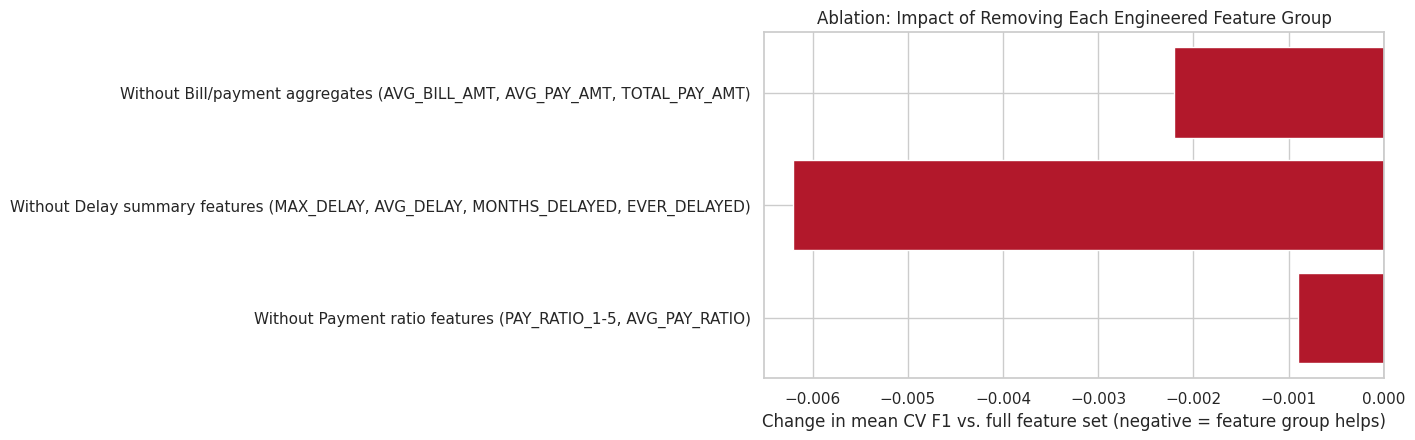

In [29]:
plot_df = ablation_df.drop(index="All features (baseline)")

plt.figure(figsize=(8, 4.5))
colors = ["#b2182b" if d < 0 else "#2166ac" for d in plot_df["Delta vs baseline"]]
plt.barh(plot_df.index, plot_df["Delta vs baseline"], color=colors)
plt.axvline(0, color="#555555", lw=1)
plt.xlabel("Change in mean CV F1 vs. full feature set (negative = feature group helps)")
plt.title("Ablation: Impact of Removing Each Engineered Feature Group")
plt.tight_layout()
plt.show()

### Ablation conclusions

| Feature group removed | Mean CV F1 | Delta vs. baseline (0.4828) |
|---|---|---|
| *(none - baseline, 42 features)* | 0.4828 | - |
| Payment ratio features (`PAY_RATIO_1`-`5`, `AVG_PAY_RATIO`) | 0.4819 | -0.0009 |
| Delay summary features (`MAX_DELAY`, `AVG_DELAY`, `MONTHS_DELAYED`, `EVER_DELAYED`) | 0.4767 | **-0.0062** |
| Bill/payment aggregates (`AVG_BILL_AMT`, `AVG_PAY_AMT`, `TOTAL_PAY_AMT`) | 0.4807 | -0.0022 |

- **The delay-summary features are the only group that clearly earns its place.** Removing them costs 0.0062 F1
  (roughly 40% of the baseline's fold-to-fold standard deviation of ~0.0157) - a real, if modest, drop. This
  matches Section 9's feature-importance ranking, where `MONTHS_DELAYED` and `EVER_DELAYED` were consistently
  top-3 across all models. The ablation confirms that ranking wasn't just correlation with other features - taking
  the group away measurably hurts the model.
- **The payment-ratio features are the weakest of the three groups** - a -0.0009 change that's small relative to
  the ~0.011-0.016 fold-to-fold noise in these CV scores, meaning I can't confidently distinguish this from zero
  effect. `PAY_RATIO_*` was likely redundant with the delay-status columns (`PAY_1`-`PAY_6`) and the bill/payment
  aggregates, which already capture most of the same "is this person keeping up with payments" signal from a
  different angle. If this model needed to be simpler (fewer features to maintain, faster to score), the
  payment-ratio group is the first candidate to cut.
- **The bill/payment aggregates sit in between** - a small but directionally real -0.0022 drop, consistent with
  `TOTAL_PAY_AMT` appearing in the Decision Tree's top-5 importances in Section 9.
- **Takeaway:** not every engineered feature contributes equally, and a feature-importance table alone can't tell
  you which ones are load-bearing versus just correlated with something more useful. The delay-summary features -
  the ones distilling *how many months* and *how recently* a client fell behind - are doing the real work here.
  The payment-ratio features were a reasonable hypothesis to test (I initially expected them to be a strong
  signal), but the ablation shows they added complexity without adding much the model didn't already have.

## 11. Conclusion

### Model performance

| Model | Accuracy | Precision | Recall | F1 | Defaults caught | Defaults missed |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.760 | 0.466 | 0.577 | 0.515 | 957 | 702 |
| Ridge Regression | 0.770 | 0.483 | 0.558 | 0.518 | 926 | 733 |
| Decision Tree | 0.765 | 0.475 | 0.585 | **0.524** | **971** | **688** |

- **Logistic Regression** is the simplest and easiest to explain of the three, but that same rigidity means it can only draw a straight-line-style boundary between "default" and "no default." 
- **Ridge Regression** gets the highest accuracy and precision by a small margin, but that comes
  at the cost of the *lowest* recall of the three (0.558) - it misses the most actual defaulters
  (733 false "no default" predictions). Shrinking coefficients toward zero made it more
  conservative about flagging risk, which is the wrong direction for this problem.
- **Decision Tree** wins on both F1 and Recall, and the confusion matrices make the practical
  impact concrete: it catches 971 of the 1,659 actual defaulters in the test set (the most of any
  model) while missing only 688 (the fewest). Being able to split on `PAY_1` and the engineered
  delay features non-linearly, rather than as a single linear weighted sum, seems to let it draw a
  tighter boundary around the highest-risk clients.

**Recommended model: Decision Tree.** Missing a real defaulter is more
costly than a false alarm here, since it means a client who is about to default keeps getting
extended credit unflagged. On that basis the Decision Tree is the clear choice - not only the
highest F1, but specifically the highest Recall and the best confusion-matrix trade-off of true
defaults caught vs. defaults missed among the three.

That choice matters more than usual for this particular dataset: the records span April-September
2005, which sits right in the middle of Taiwan's credit card and cash card debt crisis -
a period of rapidly building household over-indebtedness that peaked around 2006. Default predictions are signals a bank would want in order to act *during* a building crisis.

### My thoughts on F1 of 0.524 

Taken at face value, 0.524 isn't a strong score - the model gets roughly half of its "default"
predictions right and catches about 59% of actual defaulters. That's understandable, though, given
what's driving it:

- **Crisis-period noise:** during a systemic debt crisis, repayment behavior is likely less stable
  and less predictable from account-level data alone than in normal times - the same `PAY_1` value
  or credit limit may carry different risk depending on how the crisis was progressing that month.
- **Missing risk factors:** everything the model has to work with comes from one bank's own
  records of one credit card. A more accurate model would likely need data this dataset doesn't
  have - especially **credit bureau exposure across institutions** (a defining feature of the crisis
  was clients revolving debt across *multiple* card and cash-card issuers at once, which is
  invisible to any single bank's data), along with **income** (a real debt-to-income signal
  instead of just the bill/payment history) and some **macro or timing signal** (e.g. where in the
  crisis's build-up a given month falls), which could help the model tell apart "normal" late
  payments from crisis-driven ones.

### Final Thoughts:
 If cross-institution or income data became available, I would re-run this comparison - it would likely
  move the ceiling on F1 more than further tuning of these three models would.